# Pattern Mining


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# Impostazioni grafiche
sns.set(style="whitegrid")
sns.set_theme(palette='viridis')
plt.rcParams['figure.figsize'] = [10, 6]

## 2. Caricamento dei Dati

In [2]:
# Carica il dataset
df = pd.read_csv('cleaned_dataset.csv')

# Verifica dimensioni
print(f"Dimensioni del dataset: {df.shape}")
print(f"\nPrime 5 righe:")
df.head()

Dimensioni del dataset: (21244, 29)

Prime 5 righe:


,Name,YearPublished,GameWeight,MinPlayers,MaxPlayers,ComAgeRec,InterestScore,NumWeightVotes,log_NumWeightVotes,PlaytimeComAvg,...,Kickstarted,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,Assassin's Creed: Arena,2014,1.8333,2,4,8.0,199.333333,6,1.945910,30.0,...,0,0,0,0,0,0,0,0,0,1
1,Bag of Chips,2021,1.0000,2,5,8.0,43.666667,6,1.945910,17.5,...,0,0,0,0,0,0,0,0,0,2
2,Gùgōng: Deluxe Big Box,2020,3.6667,1,5,10.0,311.333333,9,2.302585,90.0,...,0,0,0,0,0,0,0,0,0,3
3,LetterFlip,2004,1.3077,2,2,7.0,54.333333,13,2.639057,20.0,...,0,0,0,0,0,0,0,0,0,1
4,Treasures of Cibola,2019,1.5000,2,4,10.0,82.333333,2,1.098612,17.5,...,0,0,0,0,0,0,0,0,0,2


In [3]:
# Info sul dataset
print("Informazioni sul dataset:")
df.info()

Informazioni sul dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21244 entries, 0 to 21243
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    21244 non-null  object 
 1   YearPublished           21244 non-null  int64  
 2   GameWeight              21244 non-null  float64
 3   MinPlayers              21244 non-null  int64  
 4   MaxPlayers              21244 non-null  int64  
 5   ComAgeRec               21244 non-null  float64
 6   InterestScore           21244 non-null  float64
 7   NumWeightVotes          21244 non-null  int64  
 8   log_NumWeightVotes      21244 non-null  float64
 9   PlaytimeComAvg          21244 non-null  float64
 10  NumUserRatings          21244 non-null  int64  
 11  log_NumUserRatings      21244 non-null  float64
 12  NumAlternates           21244 non-null  int64  
 13  NumAlternates_log       21244 non-null  float64
 14  NumExpansion

## 3. Discretizzazione delle Variabili Continue

Il pattern mining richiede variabili categoriche. Convertiamo le variabili numeriche selezionate in categorie.

**Variabili selezionate per l'analisi:**
- `GameWeight` → Complessità del gioco
- `PlaytimeComAvg` → Durata media
- `YearPublished` → Epoca di pubblicazione
- `NumUserRatings` → Popolarità
- `Rating` → **TARGET** (da predire)
- Categorie binarie (`Cat:*`) → Generi del gioco

### 3.1 Discretizzazione di GameWeight (Complessità)

GameWeight - Min: 1.00, Max: 5.00
Mediana: 2.00, Media: 2.04


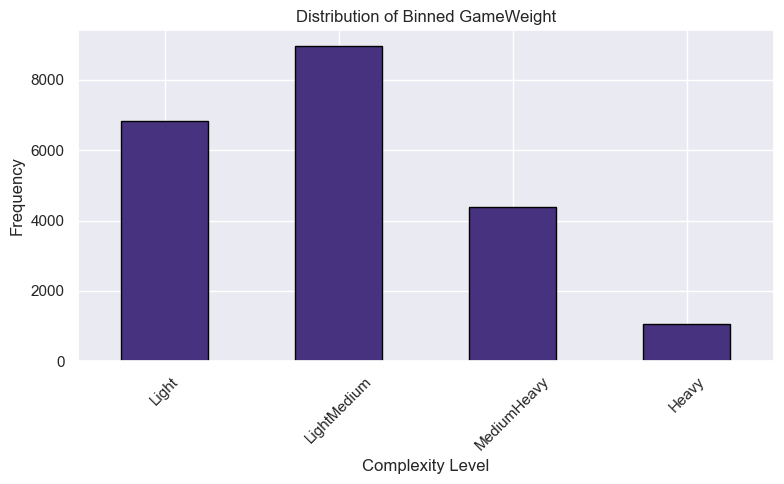

Weight_binned
Light          6826
LightMedium    8959
MediumHeavy    4393
Heavy          1066
Name: count, dtype: int64


In [5]:
# Analisi della distribuzione
print(f"GameWeight - Min: {df['GameWeight'].min():.2f}, Max: {df['GameWeight'].max():.2f}")
print(f"Mediana: {df['GameWeight'].median():.2f}, Media: {df['GameWeight'].mean():.2f}")

# Bin basati sulla scala standard di BGG (1-5)
bins_weight = [0, 1.5, 2.5, 3.5, float('inf')]
labels_weight = ['Light', 'LightMedium', 'MediumHeavy', 'Heavy']

df['Weight_binned'] = pd.cut(df['GameWeight'], bins=bins_weight, labels=labels_weight)

# Visualizza distribuzione
fig, ax = plt.subplots(figsize=(8, 5))
df['Weight_binned'].value_counts().sort_index().plot(kind='bar', ax=ax, edgecolor='black')
plt.title('Distribution of Binned GameWeight')
plt.xlabel('Complexity Level')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(df['Weight_binned'].value_counts().sort_index())

### 3.2 Discretizzazione di PlaytimeComAvg (Durata)

PlaytimeComAvg - Min: 1, Max: 8000
Mediana: 45, Media: 74


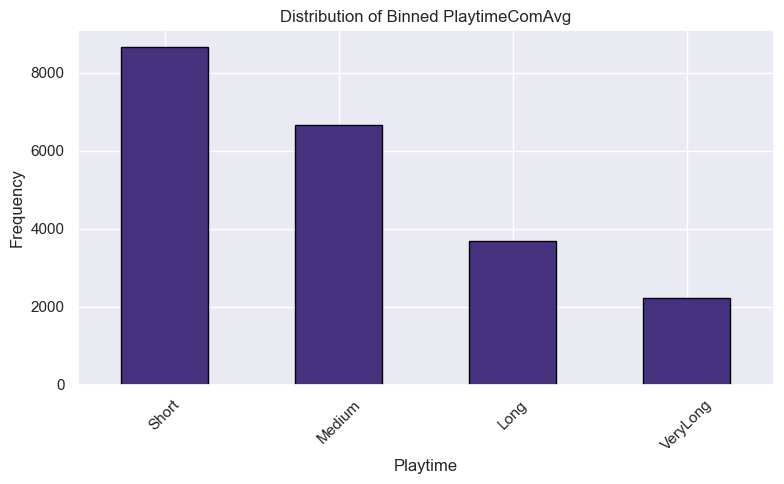

Playtime_binned
Short       8659
Medium      6669
Long        3691
VeryLong    2225
Name: count, dtype: int64


In [7]:
# Analisi della distribuzione
print(f"PlaytimeComAvg - Min: {df['PlaytimeComAvg'].min():.0f}, Max: {df['PlaytimeComAvg'].max():.0f}")
print(f"Mediana: {df['PlaytimeComAvg'].median():.0f}, Media: {df['PlaytimeComAvg'].mean():.0f}")

# Bin basati sulle categorie tipiche dei giochi
bins_time = [0, 30, 60, 120, float('inf')]
labels_time = ['Short', 'Medium', 'Long', 'VeryLong']

df['Playtime_binned'] = pd.cut(df['PlaytimeComAvg'], bins=bins_time, labels=labels_time)

# Visualizza
fig, ax = plt.subplots(figsize=(8, 5))
df['Playtime_binned'].value_counts().sort_index().plot(kind='bar', ax=ax, edgecolor='black')
plt.title('Distribution of Binned PlaytimeComAvg')
plt.xlabel('Playtime')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(df['Playtime_binned'].value_counts().sort_index())

### 3.3 Discretizzazione di YearPublished (Epoca)

YearPublished - Min: 1950, Max: 2021


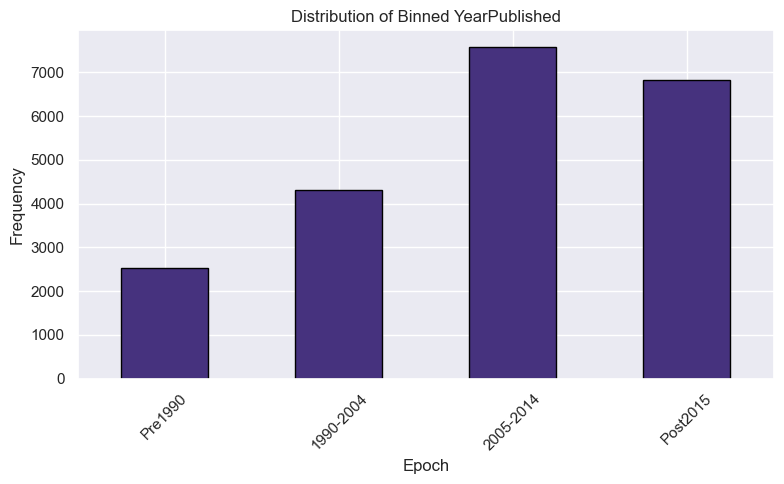

Year_binned
Pre1990      2533
1990-2004    4304
2005-2014    7583
Post2015     6824
Name: count, dtype: int64


In [8]:
# Analisi della distribuzione
print(f"YearPublished - Min: {df['YearPublished'].min()}, Max: {df['YearPublished'].max()}")

# Bin per decadi significative nell'industria dei board games
bins_year = [-float('inf'), 1990, 2005, 2015, float('inf')]
labels_year = ['Pre1990', '1990-2004', '2005-2014', 'Post2015']

df['Year_binned'] = pd.cut(df['YearPublished'], bins=bins_year, labels=labels_year)

# Visualizza distribuzione
fig, ax = plt.subplots(figsize=(8, 5))
df['Year_binned'].value_counts().sort_index().plot(kind='bar', ax=ax, edgecolor='black')
plt.title('Distribution of Binned YearPublished')
plt.xlabel('Epoch')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(df['Year_binned'].value_counts().sort_index())

### 3.4 Discretizzazione di NumUserRatings (Popolarità)

NumUserRatings - Min: 30, Max: 108101
Quartili: Q1=56, Q2=124, Q3=398


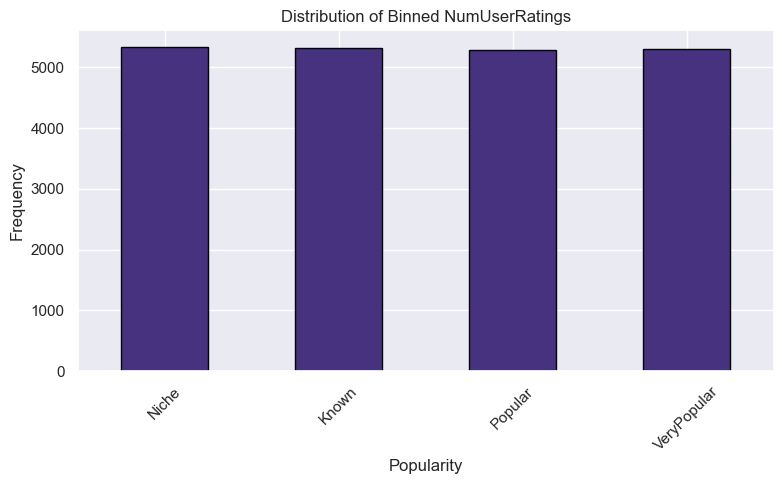

Popularity_binned
Niche          5341
Known          5315
Popular        5293
VeryPopular    5295
Name: count, dtype: int64


In [9]:
# Analisi della distribuzione
print(f"NumUserRatings - Min: {df['NumUserRatings'].min()}, Max: {df['NumUserRatings'].max()}")
print(f"Quartili: Q1={df['NumUserRatings'].quantile(0.25):.0f}, Q2={df['NumUserRatings'].quantile(0.5):.0f}, Q3={df['NumUserRatings'].quantile(0.75):.0f}")

# Bin basati sui quartili
bins_pop = [0, 56, 124, 400, float('inf')]
labels_pop = ['Niche', 'Known', 'Popular', 'VeryPopular']

df['Popularity_binned'] = pd.cut(df['NumUserRatings'], bins=bins_pop, labels=labels_pop)

# Visualizza
fig, ax = plt.subplots(figsize=(8, 5))
df['Popularity_binned'].value_counts().sort_index().plot(kind='bar', ax=ax, edgecolor='black')
plt.title('Distribution of Binned NumUserRatings')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(df['Popularity_binned'].value_counts().sort_index())

### 3.5 Mappatura di Rating (Variabile Target)

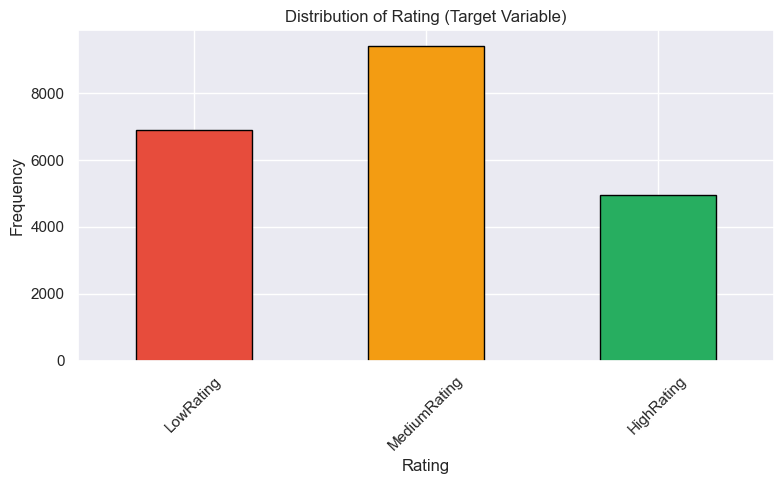

Distribuzione assoluta:
Rating_binned
MediumRating    9408
LowRating       6891
HighRating      4945
Name: count, dtype: int64

Distribuzione percentuale:
Rating_binned
MediumRating    44.29
LowRating       32.44
HighRating      23.28
Name: count, dtype: float64


In [11]:
# Converti Rating numerico in etichette leggibili
rating_mapping = {1: 'LowRating', 2: 'MediumRating', 3: 'HighRating'}
df['Rating_binned'] = df['Rating'].map(rating_mapping)

# Visualizza
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c', '#f39c12', '#27ae60']  # rosso, arancione, verde
df['Rating_binned'].value_counts().reindex(['LowRating', 'MediumRating', 'HighRating']).plot(
    kind='bar', ax=ax, color=colors, edgecolor='black')
plt.title('Distribution of Rating (Target Variable)')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Distribuzione assoluta:")
print(df['Rating_binned'].value_counts())
print(f"\nDistribuzione percentuale:")
print((df['Rating_binned'].value_counts() / len(df) * 100).round(2))

### 3.6 Riepilogo Variabili Binarie (Categorie di Gioco)

In [12]:
# Distribuzione delle categorie binarie
binary_cols = ['Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family', 
               'Cat:Abstract', 'Cat:Party', 'Cat:Childrens']

print("Distribution of Cat:*")
print("=" * 50)
for col in binary_cols:
    count_1 = (df[col] == 1).sum()
    pct = count_1 / len(df) * 100
    print(f"{col:20} -> {count_1:5} giochi ({pct:5.1f}%)")

Distribution of Cat:*
Cat:Thematic         ->  1215 giochi (  5.7%)
Cat:Strategy         ->  2308 giochi ( 10.9%)
Cat:War              ->  3494 giochi ( 16.4%)
Cat:Family           ->  2247 giochi ( 10.6%)
Cat:Abstract         ->  1021 giochi (  4.8%)
Cat:Party            ->   582 giochi (  2.7%)
Cat:Childrens        ->   828 giochi (  3.9%)


### 3.7 Summary of Discretization

The following table summarizes the discretization of continuous variables into categorical bins:

| Variable | Categories (Ranges) |
|----------|---------------------|
| GameWeight | Light (1-1.5), LightMedium (1.5-2.5), MediumHeavy (2.5-3.5), Heavy (3.5-5) |
| PlaytimeComAvg | Short (0-30), Medium (30-60), Long (60-120), VeryLong (>120) |
| YearPublished | Pre1990, 1990-2004, 2005-2014, Post2015 |
| NumUserRatings | Niche (Q1), Known (Q2), Popular (Q3), VeryPopular (Q4) |
| Rating | LowRating (1), MediumRating (2), HighRating (3) |

## 4. Creazione delle Transazioni

Ogni gioco diventa una "transazione" con tutti i suoi attributi come "item".

In [13]:
# Colonne categoriche discretizzate
columns_categorical = [
    'Weight_binned', 
    'Playtime_binned',
    'Year_binned',
    'Popularity_binned',
    'Rating_binned'
]

# Colonne binarie (categorie di gioco)
columns_binary = ['Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family', 
                  'Cat:Abstract', 'Cat:Party', 'Cat:Childrens']

# Mappa le colonne binarie in etichette leggibili
binary_labels = {
    'Cat:Thematic': 'Thematic',
    'Cat:Strategy': 'Strategy',
    'Cat:War': 'Wargame',
    'Cat:Family': 'Family',
    'Cat:Abstract': 'Abstract',
    'Cat:Party': 'Party',
    'Cat:Childrens': 'Childrens'
}

# Crea le transazioni
transactions = []

for idx, row in df.iterrows():
    transaction = []
    
    # Aggiungi variabili categoriche
    for col in columns_categorical:
        value = str(row[col])
        if value != 'nan':
            transaction.append(value)
    
    # Aggiungi variabili binarie (solo se = 1)
    for col in columns_binary:
        if row[col] == 1:
            transaction.append(binary_labels[col])
    
    transactions.append(transaction)

# Verifica
print(f"Numero totale di transazioni: {len(transactions)}")
print(f"\nEsempi di transazioni (primi 5 giochi):")
for i in range(5):
    print(f"  {df.iloc[i]['Name'][:35]:35} -> {transactions[i]}")

Numero totale di transazioni: 21244

Esempi di transazioni (primi 5 giochi):
  Assassin's Creed: Arena             -> ['LightMedium', 'Short', '2005-2014', 'Popular', 'LowRating']
  Bag of Chips                        -> ['Light', 'Short', 'Post2015', 'Niche', 'MediumRating']
  Gùgōng: Deluxe Big Box              -> ['Heavy', 'Long', 'Post2015', 'Popular', 'HighRating']
  LetterFlip                          -> ['Light', 'Short', '1990-2004', 'Known', 'LowRating']
  Treasures of Cibola                 -> ['Light', 'Short', 'Post2015', 'Known', 'MediumRating']


## 5. Codifica One-Hot (TransactionEncoder)

In [14]:
# Applica TransactionEncoder
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

# Verifica
print(f"Dimensioni matrice codificata: {df_encoded.shape}")
print(f"\nColonne (items) - {len(df_encoded.columns)} totali:")
print(list(df_encoded.columns))
print(f"\nPrime 5 righe:")
df_encoded.head()

Dimensioni matrice codificata: (21244, 26)

Colonne (items) - 26 totali:
['1990-2004', '2005-2014', 'Abstract', 'Childrens', 'Family', 'Heavy', 'HighRating', 'Known', 'Light', 'LightMedium', 'Long', 'LowRating', 'Medium', 'MediumHeavy', 'MediumRating', 'Niche', 'Party', 'Popular', 'Post2015', 'Pre1990', 'Short', 'Strategy', 'Thematic', 'VeryLong', 'VeryPopular', 'Wargame']

Prime 5 righe:


,1990-2004,2005-2014,Abstract,Childrens,Family,Heavy,HighRating,Known,Light,LightMedium,...,Party,Popular,Post2015,Pre1990,Short,Strategy,Thematic,VeryLong,VeryPopular,Wargame
0,False,True,False,False,False,False,False,False,False,True,...,False,True,False,False,True,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,True,False,True,False,False,False,False,False
2,False,False,False,False,False,True,True,False,False,False,...,False,True,True,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,True,True,False,...,False,False,False,False,True,False,False,False,False,False
4,False,False,False,False,False,False,False,True,True,False,...,False,False,True,False,True,False,False,False,False,False


---
## 6. Frequent Pattern Extraction

Estraiamo gli itemset frequenti utilizzando diversi valori di supporto per analizzare come cambia il numero di pattern.

### 6.1 Analisi al variare del Supporto Minimo

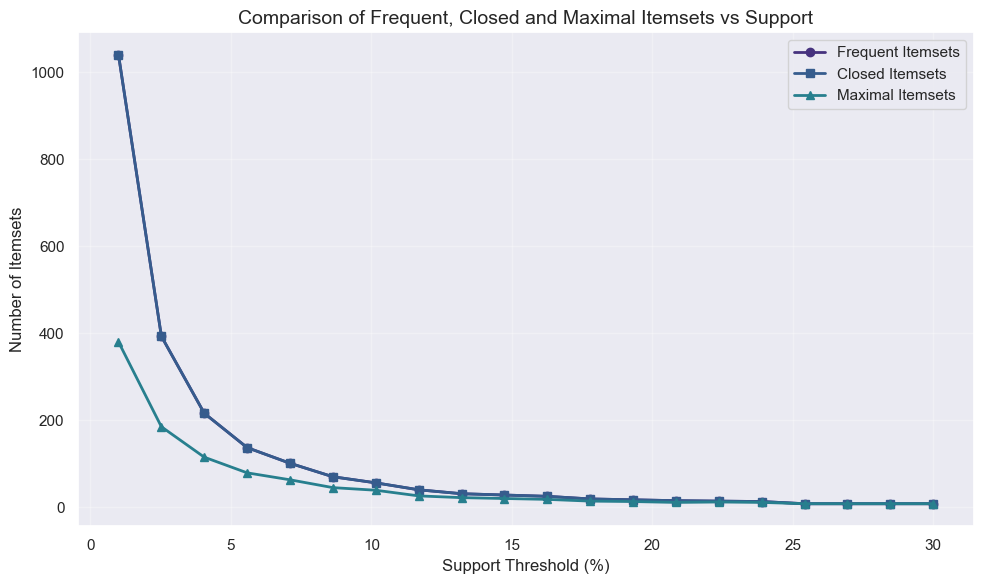


Riepilogo:
Support      Frequent     Closed       Maximal     
------------------------------------------------
     1.0%    1040         1040         380         
     4.1%    216          216          115         
     7.1%    101          101          63          
    10.2%    56           56           39          
    13.2%    31           31           22          
    16.3%    25           25           18          
    19.3%    17           17           13          
    22.4%    14           14           12          
    25.4%    8            8            8           
    28.5%    8            8            8           


In [17]:
# Range di supporti da testare
min_support = 0.01
max_support = 0.30
support_values = np.linspace(min_support, max_support, 20)

frequent_counts = []
closed_counts = []
maximal_counts = []

for supp in support_values:
    # Itemset frequenti
    freq = apriori(df_encoded, min_support=supp, use_colnames=True)
    frequent_counts.append(len(freq))
    
    if len(freq) > 0:
        # Closed itemsets: non sono subset di altri con lo stesso supporto
        closed = freq[freq.apply(
            lambda row: not any(
                set(row['itemsets']).issubset(set(other)) and 
                row['support'] == freq[freq['itemsets'] == other]['support'].values[0]
                for other in freq['itemsets'] if row['itemsets'] != other
            ), axis=1
        )]
        closed_counts.append(len(closed))
        
        # Maximal itemsets: non sono subset di nessun altro
        maximal = freq[freq['itemsets'].apply(
            lambda x: not any(x < y for y in freq['itemsets'])
        )]
        maximal_counts.append(len(maximal))
    else:
        closed_counts.append(0)
        maximal_counts.append(0)

# Grafico
plt.figure(figsize=(10, 6))
plt.plot(support_values * 100, frequent_counts, 'o-', label='Frequent Itemsets', linewidth=2)
plt.plot(support_values * 100, closed_counts, 's-', label='Closed Itemsets', linewidth=2)
plt.plot(support_values * 100, maximal_counts, '^-', label='Maximal Itemsets', linewidth=2)
plt.xlabel('Support Threshold (%)', fontsize=12)
plt.ylabel('Number of Itemsets', fontsize=12)
plt.title('Comparison of Frequent, Closed and Maximal Itemsets vs Support', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tabella riassuntiva
print("\nRiepilogo:")
print(f"{'Support':<12} {'Frequent':<12} {'Closed':<12} {'Maximal':<12}")
print("-" * 48)
for i in range(0, len(support_values), 2):  # mostra ogni 2
    print(f"{support_values[i]*100:>8.1f}%    {frequent_counts[i]:<12} {closed_counts[i]:<12} {maximal_counts[i]:<12}")

All frequent itemsets were also closed itemsets, meaning there was no redundancy in the discovered patterns. This is likely due to the limited number of features used in the analysis (12 features), which reduces the number of possible itemset combinations and makes support value collisions less likely.

### 6.2 Scelta del Supporto e Estrazione Itemset Frequenti

In [18]:
# PARAMETRI SCELTI
MIN_SUPPORT = 0.10  # 10%

print(f"Parametri scelti:")
print(f"  - Supporto minimo: {MIN_SUPPORT*100}%")
print(f"  - Numero minimo di giochi per pattern: {int(MIN_SUPPORT * len(df))}")

Parametri scelti:
  - Supporto minimo: 10.0%
  - Numero minimo di giochi per pattern: 2124


In [19]:
# Estrai itemset frequenti con Apriori
frequent_itemsets_apriori = apriori(df_encoded, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets_apriori = frequent_itemsets_apriori.sort_values('support', ascending=False).reset_index(drop=True)

print(f"Numero di itemset frequenti (Apriori): {len(frequent_itemsets_apriori)}")
print(f"\nItemset frequenti:")
frequent_itemsets_apriori

Numero di itemset frequenti (Apriori): 59

Itemset frequenti:


,support,itemsets
0,0.442854,(MediumRating)
1,0.421719,(LightMedium)
2,0.407597,(Short)
3,0.356948,(2005-2014)
4,0.324374,(LowRating)
5,0.321314,(Light)
6,0.321220,(Post2015)
7,0.313924,(Medium)
8,0.251412,(Niche)
9,0.250188,(Known)


In [20]:
# Estrai con FP-Growth per confronto
frequent_itemsets_fpgrowth = fpgrowth(df_encoded, min_support=MIN_SUPPORT, use_colnames=True)

print(f"Confronto algoritmi:")
print(f"  - Apriori: {len(frequent_itemsets_apriori)} itemsets")
print(f"  - FP-Growth: {len(frequent_itemsets_fpgrowth)} itemsets")
print(f"  - Risultati identici: {len(frequent_itemsets_apriori) == len(frequent_itemsets_fpgrowth)}")

Confronto algoritmi:
  - Apriori: 59 itemsets
  - FP-Growth: 59 itemsets
  - Risultati identici: True


### 6.3 Itemset Massimali

In [21]:
# Calcola itemset massimali
maximal_itemsets = frequent_itemsets_apriori[
    frequent_itemsets_apriori['itemsets'].apply(
        lambda x: not any(x < y for y in frequent_itemsets_apriori['itemsets'])
    )
]

print(f"Numero di itemset frequenti: {len(frequent_itemsets_apriori)}")
print(f"Numero di itemset massimali: {len(maximal_itemsets)}")
print(f"\nItemset massimali:")
maximal_itemsets

Numero di itemset frequenti: 59
Numero di itemset massimali: 38

Itemset massimali:


,support,itemsets
14,0.210695,"(LightMedium, MediumRating)"
15,0.206788,(MediumHeavy)
18,0.185888,"(Medium, LightMedium)"
21,0.173743,(Long)
22,0.170119,"(2005-2014, MediumRating)"
24,0.164470,(Wargame)
25,0.153173,"(LightMedium, Short)"
26,0.150725,"(Post2015, LightMedium)"
27,0.147901,"(2005-2014, LightMedium)"
28,0.145924,"(Post2015, MediumRating)"


Based on the analysis, a support value of 0.10 was selected, yielding 59 frequent itemsets and 38 maximal itemsets

## Confidence

Itemset frequenti estratti: 59


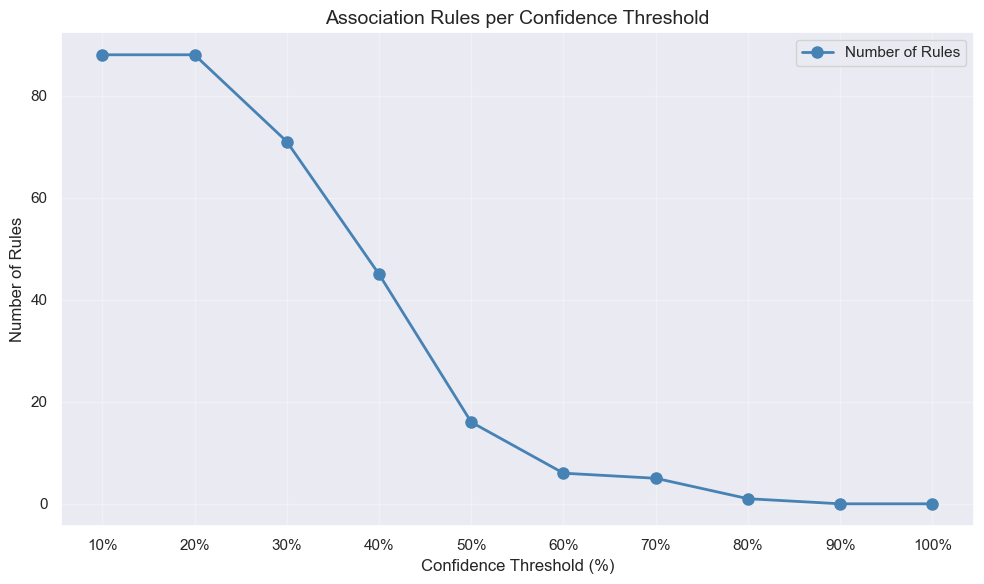


Riepilogo: Numero di regole per ogni soglia di confidence
Confidence      Num. Rules     
---------------------------------------------
        10%      88             
        20%      88             
        30%      71             
        40%      45             
        50%      16             
        60%      6              
        70%      5              
        80%      1              
        90%      0              
       100%      0              


In [22]:
# Prima estraiamo gli itemset frequenti con il supporto scelto
MIN_SUPPORT = 0.10  # 10% - scelto dal grafico precedente (elbow method)

frequent_itemsets = apriori(df_encoded, min_support=MIN_SUPPORT, use_colnames=True)
print(f"Itemset frequenti estratti: {len(frequent_itemsets)}")

# Testiamo diversi valori di confidence per trovare quello ottimale
confidence_values = np.linspace(0.1, 1.0, 10)  # Da 10% a 100%
num_rules_per_confidence = []

for conf in confidence_values:
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=conf)
    num_rules_per_confidence.append(len(rules))

# Creiamo il grafico
plt.figure(figsize=(10, 6))
plt.plot(confidence_values * 100, num_rules_per_confidence, 'o-', linewidth=2, markersize=8, color='steelblue', label='Number of Rules')
plt.xlabel('Confidence Threshold (%)', fontsize=12)
plt.ylabel('Number of Rules', fontsize=12)
plt.title('Association Rules per Confidence Threshold', fontsize=14)
plt.xticks(confidence_values * 100, [f'{int(c*100)}%' for c in confidence_values])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Tabella riassuntiva
print("\nRiepilogo: Numero di regole per ogni soglia di confidence")
print("=" * 45)
print(f"{'Confidence':<15} {'Num. Rules':<15}")
print("-" * 45)
for i, conf in enumerate(confidence_values):
    print(f"{conf*100:>10.0f}%      {num_rules_per_confidence[i]:<15}")

An iterative approach, supported by visualization, was employed to identify the optimal confidence value. As shown in Figure X, the number of association rules decreases as the confidence threshold increases. A threshold of 50% was selected as it represents the elbow point, balancing the trade-off between having enough meaningful rules and filtering out weak associations.

In [24]:
MIN_CONFIDENCE = 0.50  # 50%

print(f"\n Confidence selezionata: {MIN_CONFIDENCE*100:.0f}%")
min_threshold=MIN_CONFIDENCE


 Confidence selezionata: 50%


---
## 7. Association Rules Extraction

Estraiamo le regole associative dagli itemset frequenti.

### 7.1 Estrazione Regole con Apriori

In [25]:
# Genera regole associative
rules_apriori = association_rules(frequent_itemsets_apriori, metric="confidence", min_threshold=MIN_CONFIDENCE)

print(f"Numero di regole trovate: {len(rules_apriori)}")
rules_apriori.info()
rules_apriori.head(10)

Numero di regole trovate: 16
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   antecedents         16 non-null     object 
 1   consequents         16 non-null     object 
 2   antecedent support  16 non-null     float64
 3   consequent support  16 non-null     float64
 4   support             16 non-null     float64
 5   confidence          16 non-null     float64
 6   lift                16 non-null     float64
 7   representativity    16 non-null     float64
 8   leverage            16 non-null     float64
 9   conviction          16 non-null     float64
 10  zhangs_metric       16 non-null     float64
 11  jaccard             16 non-null     float64
 12  certainty           16 non-null     float64
 13  kulczynski          16 non-null     float64
dtypes: float64(12), object(2)
memory usage: 1.9+ KB


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Short),(Light),0.407597,0.321314,0.240491,0.590022,1.836277,1.0,0.109525,1.655420,0.768767,0.492386,0.395924,0.669242
1,(Light),(Short),0.321314,0.407597,0.240491,0.748462,1.836277,1.0,0.109525,2.355119,0.671032,0.492386,0.575393,0.669242
2,(Medium),(LightMedium),0.313924,0.421719,0.185888,0.592143,1.404117,1.0,0.053500,1.417851,0.419499,0.338128,0.294707,0.516464
3,(LowRating),(Light),0.324374,0.321314,0.176473,0.544043,1.693180,1.0,0.072247,1.488486,0.605950,0.376104,0.328176,0.546633
4,(Light),(LowRating),0.321314,0.324374,0.176473,0.549224,1.693180,1.0,0.072247,1.498805,0.603218,0.376104,0.332802,0.546633
5,(LowRating),(Short),0.324374,0.407597,0.174920,0.539254,1.323007,1.0,0.042706,1.285747,0.361362,0.314010,0.222242,0.484201
6,(HighRating),(Post2015),0.232772,0.321220,0.136368,0.585844,1.823810,1.0,0.061597,1.638949,0.588739,0.326533,0.389853,0.505188
7,(VeryPopular),(MediumRating),0.249247,0.442854,0.127848,0.512937,1.158251,1.0,0.017468,1.143887,0.181990,0.226579,0.125788,0.400814
8,"(LowRating, Short)",(Light),0.174920,0.321314,0.126953,0.725780,2.258787,1.0,0.070749,2.474972,0.675431,0.343786,0.595955,0.560444
9,"(LowRating, Light)",(Short),0.176473,0.407597,0.126953,0.719392,1.764957,1.0,0.055023,2.111138,0.526290,0.277726,0.526322,0.515430


### 7.2 Estrazione Regole con FP-Growth

In [32]:
# Genera regole con FP-Growth
rules_fpgrowth = association_rules(frequent_itemsets_fpgrowth, metric="confidence", min_threshold=MIN_CONFIDENCE)

print(f"Confronto regole:")
print(f"  - Apriori: {len(rules_apriori)} regole")
print(f"  - FP-Growth: {len(rules_fpgrowth)} regole")
rules_fpgrowth.head(10)

Confronto regole:
  - Apriori: 16 regole
  - FP-Growth: 16 regole


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(LowRating),(Short),0.324374,0.407597,0.174920,0.539254,1.323007,1.0,0.042706,1.285747,0.361362,0.314010,0.222242,0.484201
1,(Short),(Light),0.407597,0.321314,0.240491,0.590022,1.836277,1.0,0.109525,1.655420,0.768767,0.492386,0.395924,0.669242
2,(Light),(Short),0.321314,0.407597,0.240491,0.748462,1.836277,1.0,0.109525,2.355119,0.671032,0.492386,0.575393,0.669242
3,(LowRating),(Light),0.324374,0.321314,0.176473,0.544043,1.693180,1.0,0.072247,1.488486,0.605950,0.376104,0.328176,0.546633
4,(Light),(LowRating),0.321314,0.324374,0.176473,0.549224,1.693180,1.0,0.072247,1.498805,0.603218,0.376104,0.332802,0.546633
5,"(MediumRating, Light)",(Short),0.126342,0.407597,0.100593,0.796200,1.953397,1.0,0.049097,2.906780,0.558652,0.232131,0.655977,0.521497
6,"(Short, MediumRating)",(Light),0.189371,0.321314,0.100593,0.531196,1.653197,1.0,0.039745,1.447695,0.487413,0.245294,0.309247,0.422132
7,"(LowRating, Short)",(Light),0.174920,0.321314,0.126953,0.725780,2.258787,1.0,0.070749,2.474972,0.675431,0.343786,0.595955,0.560444
8,"(LowRating, Light)",(Short),0.176473,0.407597,0.126953,0.719392,1.764957,1.0,0.055023,2.111138,0.526290,0.277726,0.526322,0.515430
9,"(Short, Light)",(LowRating),0.240491,0.324374,0.126953,0.527892,1.627418,1.0,0.048944,1.431084,0.507604,0.289906,0.301229,0.459636


Rules were extracted from the frequent itemsets using a minimum confidence threshold of 50% (min_confidence = 0.50), selected through iterative analysis (Figure Y). This yielded 16 association rules for both Apriori and FP-Growth.

---
## 8. Discussion: Association Rules Analysis

Analizziamo le regole estratte sia quantitativamente che qualitativamente.

### 8.1 Distribuzione delle Metriche

In [28]:
# Statistiche descrittive delle metriche
print("Statistiche delle regole:")
rules_apriori[['support', 'confidence', 'lift']].describe()

Statistiche delle regole:


,support,confidence,lift
count,16.000000,16.000000,16.000000
mean,0.146556,0.617873,1.716300
std,0.047446,0.105909,0.271321
min,0.100593,0.503717,1.158251
25%,0.101770,0.537239,1.608786
50%,0.127401,0.587933,1.729068
75%,0.176473,0.720989,1.847904
max,0.240491,0.814899,2.258787


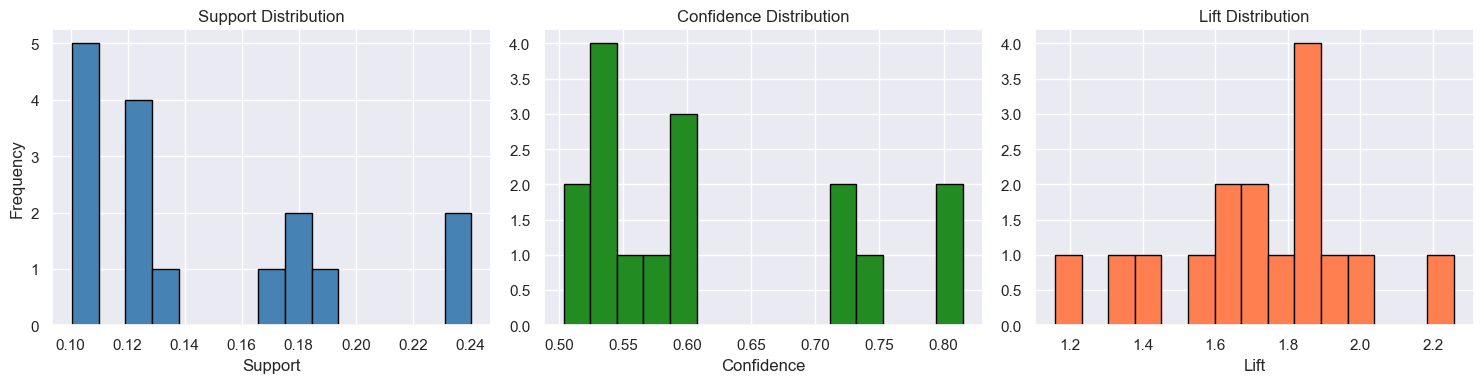

In [30]:
# Istogrammi delle metriche principali
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rules_apriori['support'], bins=15, edgecolor='black', color='steelblue')
axes[0].set_title('Support Distribution')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Frequency')

axes[1].hist(rules_apriori['confidence'], bins=15, edgecolor='black', color='forestgreen')
axes[1].set_title('Confidence Distribution')
axes[1].set_xlabel('Confidence')

axes[2].hist(rules_apriori['lift'], bins=15, edgecolor='black', color='coral')
axes[2].set_title('Lift Distribution')
axes[2].set_xlabel('Lift')

plt.tight_layout()
plt.show()

### 8.2 Scatter Plot: Support vs Confidence

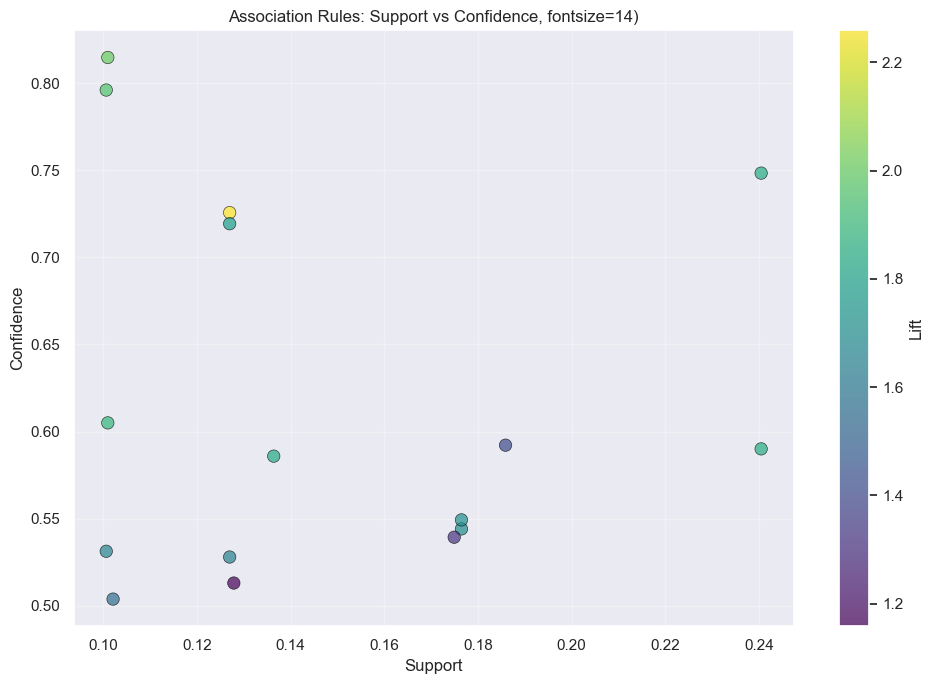

In [36]:
# Scatter Plot Support vs Confidence (colore = Lift)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(rules_apriori['support'], rules_apriori['confidence'], 
                      c=rules_apriori['lift'], cmap='viridis', alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support', fontsize=12)
plt.ylabel('Confidence', fontsize=12)
plt.title('Association Rules: Support vs Confidence, fontsize=14)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.3 Top Regole per Lift

In [37]:
# Ordina per lift
rules_sorted = rules_apriori.sort_values('lift', ascending=False)

print("Top 15 regole ordinate per Lift:")
rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15)

Top 15 regole ordinate per Lift:


,antecedents,consequents,support,confidence,lift
8,"(LowRating, Short)",(Light),0.126953,0.725780,2.258787
13,"(2005-2014, Light)",(Short),0.100923,0.814899,1.999275
14,"(MediumRating, Light)",(Short),0.100593,0.796200,1.953397
12,"(2005-2014, Short)",(Light),0.100923,0.604966,1.882787
1,(Light),(Short),0.240491,0.748462,1.836277
0,(Short),(Light),0.240491,0.590022,1.836277
6,(HighRating),(Post2015),0.136368,0.585844,1.823810
9,"(LowRating, Light)",(Short),0.126953,0.719392,1.764957
3,(LowRating),(Light),0.176473,0.544043,1.693180
4,(Light),(LowRating),0.176473,0.549224,1.693180


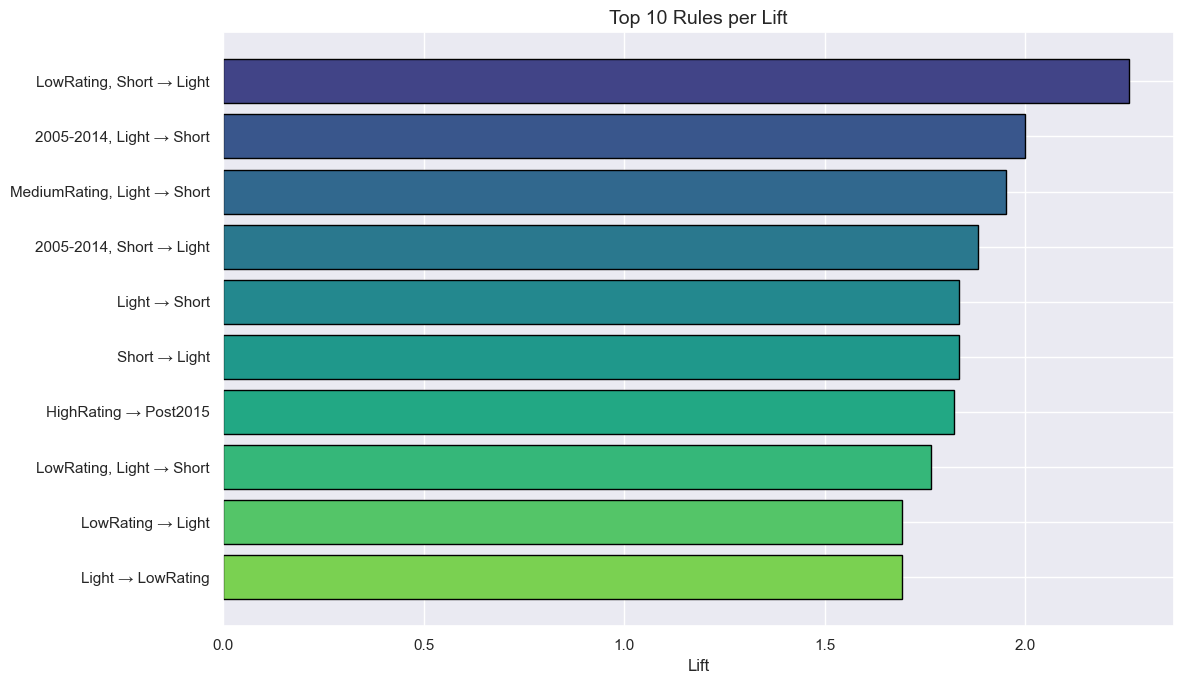

In [35]:
# Visualizzazione grafica delle top regole
rules_apriori['antecedents_str'] = rules_apriori['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_apriori['consequents_str'] = rules_apriori['consequents'].apply(lambda x: ', '.join(list(x)))
rules_apriori['rule_str'] = rules_apriori['antecedents_str'] + ' → ' + rules_apriori['consequents_str']

top_rules = rules_apriori.nlargest(10, 'lift')

plt.figure(figsize=(12, 7))
y_pos = range(len(top_rules))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_rules)))
plt.barh(y_pos, top_rules['lift'], color=colors, edgecolor='black')
plt.yticks(y_pos, top_rules['rule_str'])
plt.xlabel('Lift', fontsize=12)
plt.title('Top 10 Rules per Lift', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 9. Target Prediction: Association Rules for Rating

For predicting the target variable using Pattern Mining, we focus on **LowRating**, 
as it yielded the strongest and most interpretable association rules. 
This analysis reveals which game characteristics are associated with lower user ratings.

In [39]:
# Filter rules with LowRating as consequent
rules_lowrating = rules_apriori[rules_apriori['consequents'] == frozenset({'LowRating'})]
rules_lowrating = rules_lowrating.sort_values('lift', ascending=False)

print(f"Rules predicting LowRating: {len(rules_lowrating)}")
print("\nRules ranked by Lift:")
rules_lowrating[['antecedents', 'consequents', 'antecedent support', 'consequent support', 
                 'support', 'confidence', 'lift', 'leverage']]

Rules predicting LowRating: 3

Rules ranked by Lift:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage
4,(Light),(LowRating),0.321314,0.324374,0.176473,0.549224,1.693180,0.072247
10,"(Short, Light)",(LowRating),0.240491,0.324374,0.126953,0.527892,1.627418,0.048944
11,(1990-2004),(LowRating),0.202598,0.324374,0.102052,0.503717,1.552891,0.036335


The following table presents the association rules predicting LowRating, ranked by lift:

| Antecedents | Consequent | Support | Confidence | Lift | Leverage |
|-------------|------------|---------|------------|------|----------|
| (Light) | (LowRating) | 0.176 | 0.549 | 1.693 | 0.072 |
| (Short, Light) | (LowRating) | 0.127 | 0.528 | 1.627 | 0.055 |
| (1990-2004) | (LowRating) | 0.102 | 0.504 | 1.553 | 0.036 |

---
## 10. Exploit: Using Association Rules for Prediction

Based on the extracted rules, we can predict whether a game is likely to have a **LowRating** 
based on its characteristics. The following rules are used for prediction:

| Antecedents | Consequent | Confidence | Lift |
|-------------|------------|------------|------|
| (Light) | LowRating | 54.9% | 1.69 |
| (Short, Light) | LowRating | 52.8% | 1.63 |
| (1990-2004) | LowRating | 50.4% | 1.55 |

### 10.1 Selezione della Miglior Regola per LowRating


In [45]:
print("=" * 70)
print("BEST RULE FOR PREDICTING LowRating")
print("=" * 70)

if len(rules_lowrating) > 0:
    best_rule = rules_lowrating.iloc[0]
    antecedents_best = list(best_rule['antecedents'])
    
    print(f"\nTo predict: LowRating")
    print(f"How? {', '.join(antecedents_best)}")
    print(f"\nMetrics:")
    print(f"  - Support: {best_rule['support']:.2%}")
    print(f"  - Confidence: {best_rule['confidence']:.2%}")
    print(f"  - Lift: {best_rule['lift']:.2f}")
else:
    antecedents_best = None
    print("No rules found for LowRating")

BEST RULE FOR PREDICTING LowRating

To predict: LowRating
How? Light

Metrics:
  - Support: 17.65%
  - Confidence: 54.92%
  - Lift: 1.69


### 10.2 Applicazione della Regola al Dataset

In [42]:
if antecedents_best is not None:
    # Function to check if a game matches the antecedents
    def check_antecedents(transaction, antecedents):
        return all(ant in transaction for ant in antecedents)
    
    # Apply rule to all transactions
    df['predicted_lowrating'] = [check_antecedents(t, antecedents_best) for t in transactions]
    
    # Count matching games
    games_matching = df['predicted_lowrating'].sum()
    
    print(f"\nGames matching the rule: {games_matching} ({games_matching/len(df)*100:.1f}%)")
    
    # Verify prediction accuracy
    matching_games = df[df['predicted_lowrating'] == True]
    if len(matching_games) > 0:
        actual_low = (matching_games['Rating'] == 1).sum()  # 1 = LowRating
        accuracy = actual_low / len(matching_games)
        
        print(f"Of these, actually LowRating: {actual_low}")
        print(f"Rule accuracy: {accuracy:.2%}")
        
        # Distribution of ratings for matching games
        print(f"\nRating distribution for games matching the rule:")
        print(matching_games['Rating_binned'].value_counts())


Games matching the rule: 6826 (32.1%)
Of these, actually LowRating: 3749
Rule accuracy: 54.92%

Rating distribution for games matching the rule:
Rating_binned
LowRating       3749
MediumRating    2684
HighRating       393
Name: count, dtype: int64


In [43]:
print("\n" + "=" * 70)
print("SUMMARY: LowRating ASSOCIATION RULES RANKED BY LIFT")
print("=" * 70)

if len(rules_lowrating) > 0:
    summary_table = rules_lowrating[['antecedents', 'support', 'confidence', 'lift']].copy()
    summary_table['antecedents'] = summary_table['antecedents'].apply(lambda x: ', '.join(list(x)))
    summary_table = summary_table.reset_index(drop=True)
    summary_table.index = summary_table.index + 1  # Start from 1
    print(summary_table.to_string())
else:
    print("No rules found")


SUMMARY: LowRating ASSOCIATION RULES RANKED BY LIFT
    antecedents   support  confidence      lift
1         Light  0.176473    0.549224  1.693180
2  Short, Light  0.126953    0.527892  1.627418
3     1990-2004  0.102052    0.503717  1.552891


## 11. Conclusions

### Key Findings

The pattern mining analysis revealed significant associations related to game ratings:

1. **Complexity-Rating Association**: Games with **Light** complexity are 1.69 times more likely 
   to receive low ratings (confidence: 54.9%). This suggests that users prefer games with 
   more depth and strategic complexity.

2. **Combined Effect**: Games that are both **Short** and **Light** are 1.63 times more likely 
   to have low ratings, reinforcing the finding that simpler, quicker games tend to be 
   rated lower by the BoardGameGeek community.

3. **Temporal Pattern**: Games published between **1990-2004** are 1.55 times more likely 
   to have low ratings. This temporal bias is complemented by the rule **HighRating → Post2015** 
   (lift: 1.82), indicating that highly-rated games tend to be more recent publications.

### Interpretation

The temporal pattern could be explained by several factors:
- Modern games benefit from evolved design methodologies
- The BoardGameGeek community is more engaged with recent releases
- Older games may suffer from outdated mechanics or presentation
- Selection bias: only highly-regarded older games remain in active circulation

### Limitations

No strong rules were found directly predicting **HighRating** or **MediumRating** as consequents 
with the selected confidence threshold (50%). This suggests that high ratings are not strongly 
associated with any single combination of the analyzed features.

In [44]:
print("\n" + "=" * 70)
print("FINAL SUMMARY - PATTERN MINING ANALYSIS")
print("=" * 70)

print(f"\n📊 DATASET:")
print(f"   - Number of games: {len(df):,}")
print(f"   - Items in pattern mining: {len(df_encoded.columns)}")

print(f"\n⚙️ PARAMETERS:")
print(f"   - Minimum support: {MIN_SUPPORT*100:.0f}%")
print(f"   - Minimum confidence: {MIN_CONFIDENCE*100:.0f}%")

print(f"\n📈 RESULTS:")
print(f"   - Frequent itemsets: {len(frequent_itemsets_apriori)}")
print(f"   - Association rules: {len(rules_apriori)}")
print(f"   - Rules for LowRating: {len(rules_lowrating)}")

print(f"\n🎯 TARGET PREDICTION:")
print(f"   Target: LowRating")
print(f"   Best rule: {', '.join(antecedents_best) if antecedents_best else 'N/A'} → LowRating")
if len(rules_lowrating) > 0:
    print(f"   Confidence: {rules_lowrating.iloc[0]['confidence']:.1%}")
    print(f"   Lift: {rules_lowrating.iloc[0]['lift']:.2f}")

print("\n" + "=" * 70)


FINAL SUMMARY - PATTERN MINING ANALYSIS

📊 DATASET:
   - Number of games: 21,244
   - Items in pattern mining: 26

⚙️ PARAMETERS:
   - Minimum support: 10%
   - Minimum confidence: 50%

📈 RESULTS:
   - Frequent itemsets: 59
   - Association rules: 16
   - Rules for LowRating: 3

🎯 TARGET PREDICTION:
   Target: LowRating
   Best rule: Light → LowRating
   Confidence: 54.9%
   Lift: 1.69

